# Laboratorium 1: Perceptron i jego zastosowanie w klasyfikacji obrazów
### ZAAWANSOWANE METODY SZTUCZNEJ INTELIGENCJI
**Rok akademicki:** 2026/2027 - INFORMATYKA STOSOWANA II stopień

---



## 1. Perceptron - podstawowe informacje
Perceptron to prosty model sztucznego neuronu, który rozwiązuje podstawowe zadania obliczeniowe i stanowi punkt wyjścia do budowy bardziej zaawansowanych sieci neuronowych. Działa on poprzez klasyfikowanie danych wejściowych i odpowiednie ustawianie wartości wyjściowych.

### Model matematyczny pojedynczego neuronu
Poniższy diagram przedstawia architekturę perceptronu:

![Diagram Perceptronu](images/perceptron_diagram.png)

Wyjście perceptronu oblicza się według wzoru:
$$y = f(\sum_{i=1}^{n} w_ix_i + b)$$

gdzie:
- n: liczba wejść,
- x_i: wejście,
- w_i: waga,
- b: bias (stała wartość),
- f: funkcja aktywacji.

---

## 2. Separowalność liniowa
Perceptrony mogą klasyfikować dane na zbiory, które są **liniowo separowalne**. Oznacza to, że możemy postawić jedną prostą linię (w 2D) lub płaszczyznę (w 3D), która idealnie oddzieli jedną klasę od drugiej.

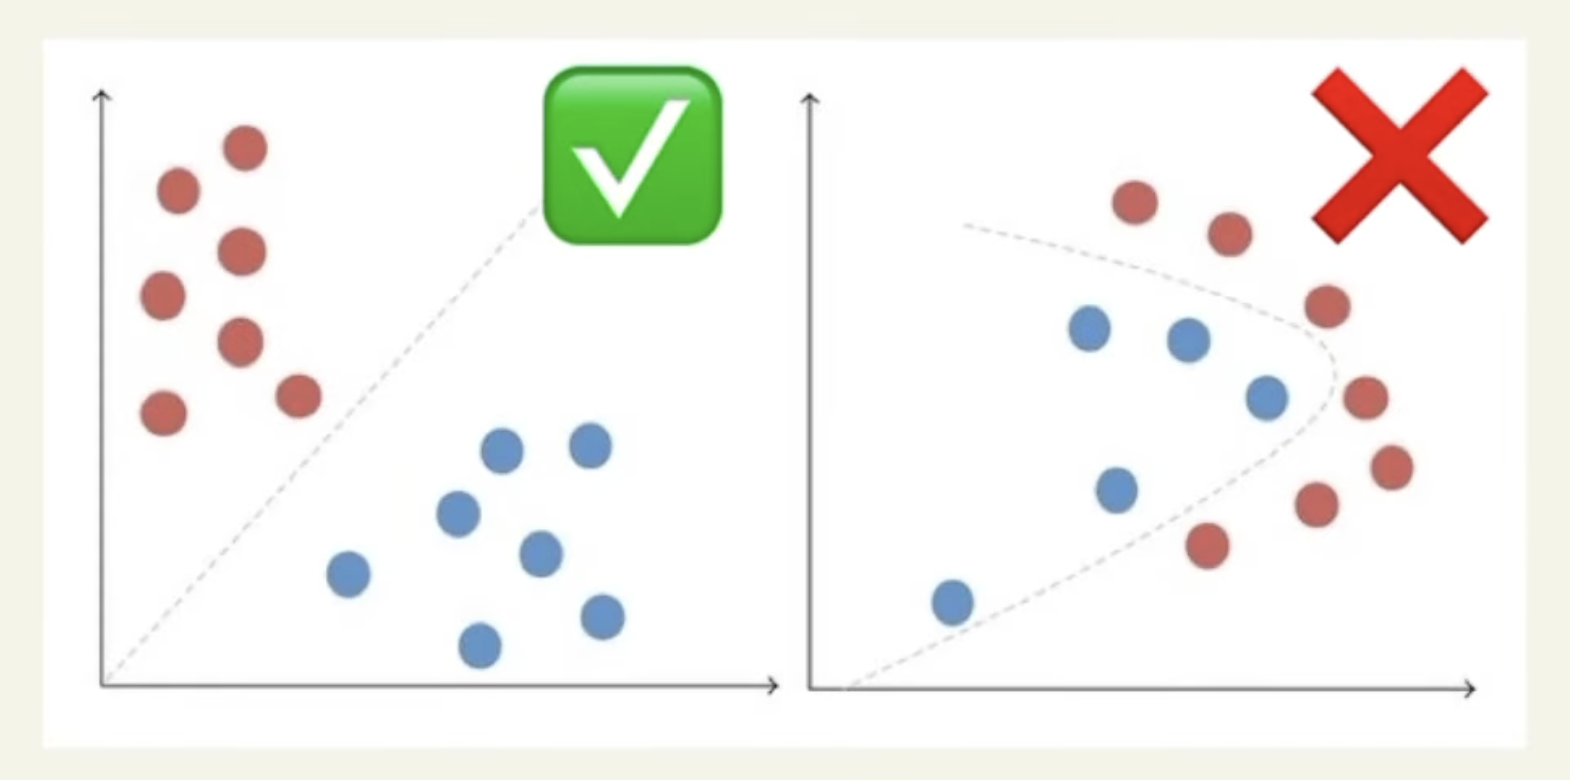

### Przykład wizualny
Poniżej zobaczysz różnicę między danymi, które perceptron potrafi rozdzielić, a takimi, które wymagają bardziej złożonych sieci (np. problem XOR).

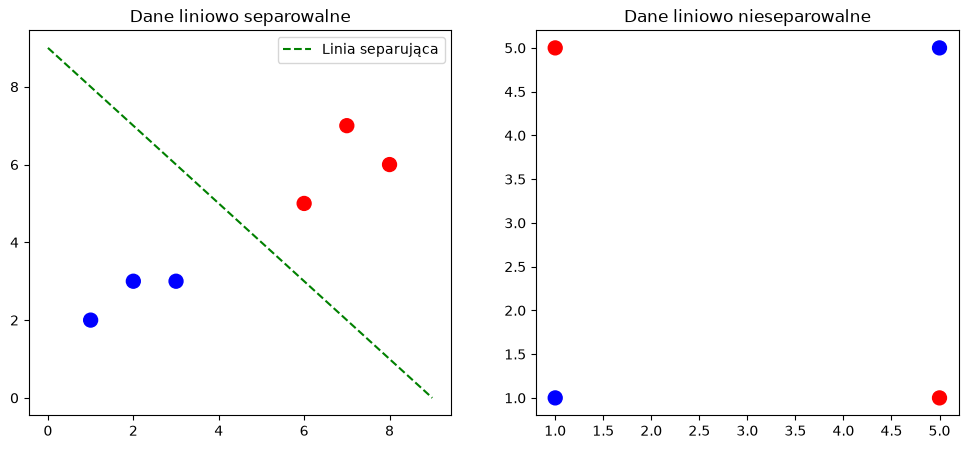

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Dane separowalne - dwa wyraźne skupiska
X_sep = np.array([[1, 2], [2, 3], [3, 3], [6, 5], [7, 7], [8, 6]])
y_sep = np.array([0, 0, 0, 1, 1, 1])

# Dane nieseparowalne - punkty są przemieszane (tzw. XOR)
X_non = np.array([[1, 1], [5, 5], [1, 5], [5, 1]])
y_non = np.array([0, 0, 1, 1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_sep[:,0], X_sep[:,1], c=y_sep, cmap='bwr', s=100)
ax1.plot([0, 9], [9, 0], 'g--', label='Linia separująca')
ax1.set_title("Dane liniowo separowalne")
ax1.legend()

ax2.scatter(X_non[:,0], X_non[:,1], c=y_non, cmap='bwr', s=100)
ax2.set_title("Dane liniowo nieseparowalne")

plt.show()

---

## 3. Dynamika uczenia: Animacja
Uczenie perceptronu polega na modyfikacji wag za każdym razem, gdy neuron „pomyli się” w klasyfikacji. 

**Uwaga dotycząca stylu kodu:**
Poniższy kod jest celowo mocno skomentowany. W profesjonalnych projektach dążymy do samo-dokumentującego się kodu, ale tutaj komentarze pełnią rolę przewodnika po teorii.

### Kluczowe pojęcia w kodzie:
- `eta` (współczynnik uczenia): Decyduje, jak duży krok wykonujemy w stronę poprawnego wyniku. Zbyt duże `eta` może powodować oscylacje.
- `epoch` (epoka): Pełny przejazd przez wszystkie dostępne punkty w zbiorze treningowym.
- `w` (wagi): Parametry, które określają nachylenie linii decyzyjnej.
- `b` (bias): Przesunięcie linii względem początku układu współrzędnych.

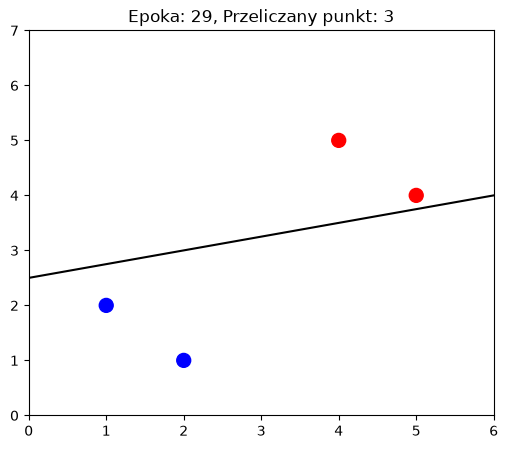

In [9]:
import time
from IPython.display import clear_output

# Definicja prostego zbioru treningowego (X - cechy, y - etykiety)
X = np.array([[1, 2], [2, 1], [4, 5], [5, 4]])
y = np.array([0, 0, 1, 1])

# Inicjalizacja parametrów modelu
w = np.array([-0.5, 0.5]) # Początkowe wagi (losowe lub startowe)
b = 0.05                   # Bias (przesunięcie)
eta = 0.05                 # Szybkość uczenia (Learning Rate)

for epoch in range(30):   # Pętla po epokach (ilość powtórzeń całego zbioru)
    for i in range(len(X)): # Iteracja po każdym punkcie z osobna
        # Klasyfikacja: suma (w*x) + b, a następnie funkcja progowa
        linear_output = np.dot(X[i], w) + b
        pred = 1 if linear_output >= 0 else 0
        
        # Reguła uczenia Perceptronu: tylko jeśli nastąpi błąd
        if pred != y[i]:
            # Aktualizacja wag: w = w + eta * (y_true - y_pred) * x
            w += eta * (y[i] - pred) * X[i]
            # Aktualizacja biasu: b = b + eta * (y_true - y_pred)
            b += eta * (y[i] - pred)
            
        # Wizualizacja procesu (renderowanie linii decyzyjnej)
        clear_output(wait=True)
        plt.figure(figsize=(6, 5))
        plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=100)
        
        # Wyliczanie współrzędnych do narysowania prostej: w[0]*x1 + w[1]*x2 + b = 0
        x_vals = np.linspace(0, 6, 100)
        if w[1] != 0:
            y_vals = -(w[0] * x_vals + b) / w[1]
            plt.plot(x_vals, y_vals, 'k-', label='Linia decyzyjna')
        
        plt.xlim(0, 6); plt.ylim(0, 7)
        plt.title(f"Epoka: {epoch}, Przeliczany punkt: {i}")
        plt.show()
        time.sleep(0.1)

---

## 4. Funkcje aktywacji
Funkcja aktywacji decyduje o „nieliniowości” neuronu. W klasycznym perceptronie używamy funkcji skokowej (Heaviside'a), ale w sieciach głębokich stosuje się funkcje ciągłe.

### Porównanie wizualne
- **Step**: Twarda klasyfikacja (0 lub 1).
- **Sigmoid**: Wynik w zakresie (0, 1), interpretowany często jako prawdopodobieństwo.
- **ReLU**: Wyłącza ujemne sygnały (ustawia 0). Standard w dzisiejszej sztucznej inteligencji.

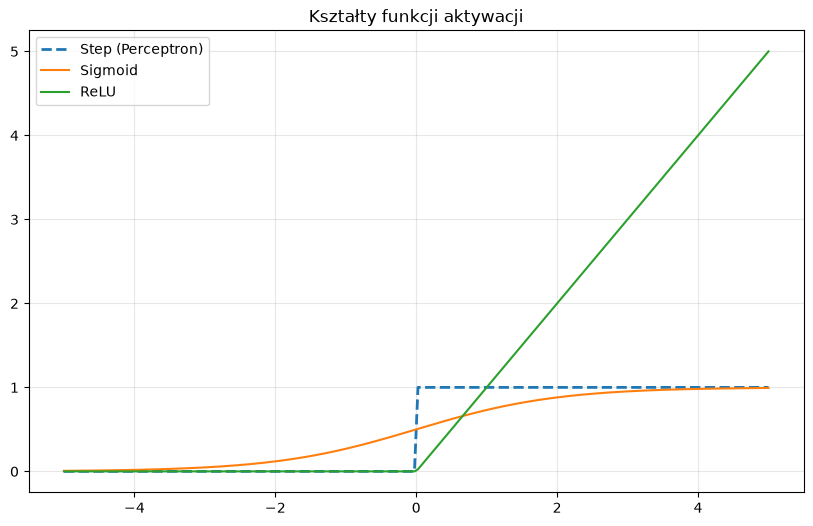

In [10]:
def sigmoid(x): return 1 / (1 + np.exp(-x))
def relu(x): return np.maximum(0, x)
def step(x): return np.where(x >= 0, 1, 0)

x_axis = np.linspace(-5, 5, 200)
plt.figure(figsize=(10, 6))
plt.plot(x_axis, step(x_axis), '--', label='Step (Perceptron)', linewidth=2)
plt.plot(x_axis, sigmoid(x_axis), label='Sigmoid')
plt.plot(x_axis, relu(x_axis), label='ReLU')
plt.grid(True, alpha=0.3)
plt.legend(); plt.title("Kształty funkcji aktywacji")
plt.show()

---

## 5. Zadanie 1: Implementacja klasy Perceptron
Twoim zadaniem jest stworzenie uniwersalnej klasy, która będzie mogła trenować się na dowolnych danych.

### Co musisz zrobić?
1. Uzupełnij metodę `predict` (oblicz sumę ważoną i zastosuj funkcję progową).
2. Uzupełnij metodę `train` o pętlę epok i regułę aktualizacji wag.
3. `eta` steruje prędkością uczenia, a `tol` to dopuszczalny błąd (jeśli osiągniesz mniejszy błąd niż `tol`, możesz przerwać naukę wcześniej).

In [12]:
import numpy as np

class Perceptron:
    def __init__(self, n, bias=True):
        # Inicjalizacja wag (n = ilość wejść)
        self.w = np.random.randn(n) * 0.01
        self.b = np.random.randn() if bias else 0

    def predict(self, x):
        x = np.asarray(x)
        z = np.dot(x, self.w) + self.b
        if z.ndim == 0:
            return 1 if z >= 0 else 0
        return np.where(z >= 0, 1, 0)

    def train(self, xx, d, eta=0.01, tol=0.0, max_epochs=100, verbose=False):
        xx = np.asarray(xx)
        d = np.asarray(d)
        
        history = []
        for epoch in range(1, max_epochs + 1):
            errors = 0
            for xi, yi in zip(xx, d):
                prediction = self.predict(xi)
                error = yi - prediction
                if error != 0:
                    self.w += eta * error * xi
                    self.b += eta * error
                    errors += 1
            
            error_rate = errors / len(xx)
            history.append(error_rate)

            if verbose:
                print(f"Epoch {epoch}: errors={errors}, error_rate={error_rate:.4f}")
            
            if error_rate <= tol:
                print(f"Trening zakończony w epoce {epoch} (błąd: {error_rate:.4f})")
                break

        return epoch, error_rate, history

    def evaluate_test(self, xx, d):
        xx = np.asarray(xx)
        d = np.asarray(d)
        preds = self.predict(xx)
        error_rate = np.mean(preds != d)
        return error_rate, preds

---

## 6. Zadanie 2: Klasyfikacja 2D i 3D
Wczytaj proste dane z plików CSV. Zobacz, czy Twój model potrafi je bezbłędnie rozdzielić.

### Starter Code:
Możesz wykorzystać poniższy szkielet do wczytania danych i wywołania treningu.

KLASYFIKACJA 2D
Trening zakończony w epoce 73 (błąd: 0.0000)
2D - Epoka: 73, Train error: 0.0000, Test accuracy: 95.00%



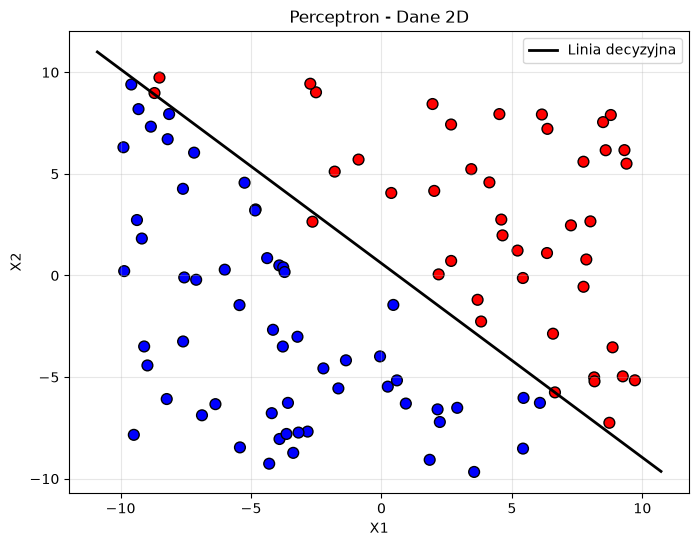

KLASYFIKACJA 3D
Trening zakończony w epoce 26 (błąd: 0.0000)
3D - Epoka: 26, Train error: 0.0000, Test accuracy: 100.00%



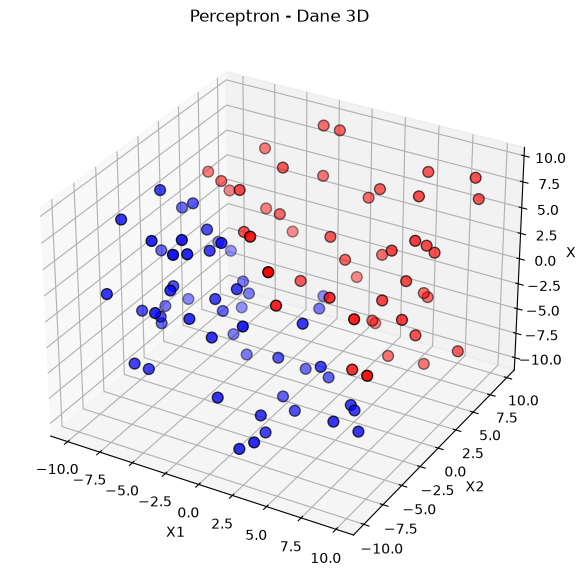

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

# ===== ZADANIE 2D =====
print("=" * 50)
print("KLASYFIKACJA 2D")
print("=" * 50)

df2d = pd.read_csv('data/2D.csv', sep=';', decimal=',')
X2d = df2d[['X1', 'X2']].values
y2d = df2d['L'].values

X2d_train, X2d_test, y2d_train, y2d_test = train_test_split(X2d, y2d, test_size=0.2, random_state=42)

model2d = Perceptron(n=2)
epoch2d, err2d, history2d = model2d.train(X2d_train, y2d_train, eta=0.01, tol=0.01, max_epochs=100, verbose=False)

test_error2d, preds2d = model2d.evaluate_test(X2d_test, y2d_test)
print(f"2D - Epoka: {epoch2d}, Train error: {err2d:.4f}, Test accuracy: {(1-test_error2d)*100:.2f}%\n")

# Wizualizacja 2D
plt.figure(figsize=(8, 6))
plt.scatter(X2d[:, 0], X2d[:, 1], c=y2d, cmap='bwr', s=60, edgecolor='k')

w0, w1 = model2d.w
b = model2d.b
x_vals = np.linspace(X2d[:, 0].min() - 1, X2d[:, 0].max() + 1, 200)
if abs(w1) > 1e-8:
    y_vals = -(w0 * x_vals + b) / w1
    plt.plot(x_vals, y_vals, 'k-', linewidth=2, label='Linia decyzyjna')
else:
    x0 = -b / w0
    plt.axvline(x=x0, color='k', linestyle='-', linewidth=2, label='Linia decyzyjna')

plt.title("Perceptron - Dane 2D")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ===== ZADANIE 3D =====
print("=" * 50)
print("KLASYFIKACJA 3D")
print("=" * 50)

df3d = pd.read_csv('data/3D.csv', sep=';', decimal=',')
X3d = df3d[['X1', 'X2', 'X3']].values
y3d = df3d['L'].values

X3d_train, X3d_test, y3d_train, y3d_test = train_test_split(X3d, y3d, test_size=0.2, random_state=42)

model3d = Perceptron(n=3)
epoch3d, err3d, history3d = model3d.train(X3d_train, y3d_train, eta=0.01, tol=0.01, max_epochs=100, verbose=False)

test_error3d, preds3d = model3d.evaluate_test(X3d_test, y3d_test)
print(f"3D - Epoka: {epoch3d}, Train error: {err3d:.4f}, Test accuracy: {(1-test_error3d)*100:.2f}%\n")

# Wizualizacja 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3d[:, 0], X3d[:, 1], X3d[:, 2], c=y3d, cmap='bwr', s=60, edgecolor='k')
ax.set_title("Perceptron - Dane 3D")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")
plt.show()

---

## 7. Zadanie 3: Klasyfikacja Cyfr (MNIST)
To zadanie polega na rozpoznawaniu różnicy między dwiema cyframi (np. 3 i 8). Każdy obrazek to 784 piksele (28x28), co oznacza, że Twój perceptron będzie miał 784 wejścia.

### Zmienne do przetworzenia:
- `X_mnist`: piksele znormalizowane do zakresu [0, 1] (podziel dane przez 255).
- `y_mnist`: etykiety zamienione na 0 i 1 (np. wszystkie trójki to 0, wszystkie ósemki to 1).

In [ ]:
# TODO: Zadanie 3 (MNIST)
# 1. Wczytaj mnist_train.csv i mnist_test.csv
# 2. Wyfiltruj tylko dwie wybrane cyfry
# 3. Wykonaj trening i sprawdź dokładność na zbiorze testowym

import pandas as pd
from sklearn.model_selection import train_test_split

print("=" * 50)
print("KLASYFIKACJA MNIST - Cyfry 3 vs 8")
print("=" * 50)

# Wczytanie danych MNIST
train_df = pd.read_csv('data/mnist_train.csv')
test_df = pd.read_csv('data/mnist_test.csv')

print(f"Oryginalny zbiór treningowy: {len(train_df)} próbek")
print(f"Oryginalny zbiór testowy: {len(test_df)} próbek")

# Wybór dwóch cyfr (3 i 8)
digits = (3, 8)
train_mask = train_df['label'].isin(digits)
test_mask = test_df['label'].isin(digits)

X_mnist_train = train_df.loc[train_mask].drop(columns='label').values.astype(np.float32) / 255.0
y_mnist_train = (train_df.loc[train_mask, 'label'] == digits[1]).astype(int).values

X_mnist_test = test_df.loc[test_mask].drop(columns='label').values.astype(np.float32) / 255.0
y_mnist_test = (test_df.loc[test_mask, 'label'] == digits[1]).astype(int).values

print(f"\nPo filtrowaniu:")
print(f"Zbiór treningowy: {len(X_mnist_train)} próbek ({digits[0]} = 0, {digits[1]} = 1)")
print(f"Zbiór testowy: {len(X_mnist_test)} próbek")

# Trenowanie (można ograniczyć do mniejszego zbioru dla przyspieszenia)
print("\nTrenowanie Perceptronu...")
model_mnist = Perceptron(n=784)
epoch_mnist, err_mnist, history_mnist = model_mnist.train(
    X_mnist_train,
    y_mnist_train,
    eta=0.01,
    tol=0.0,
    max_epochs=30,
    verbose=True
)

# Ewaluacja
test_error_mnist, preds_mnist = model_mnist.evaluate_test(X_mnist_test, y_mnist_test)
accuracy_mnist = (1 - test_error_mnist) * 100

print(f"\nMNIST ({digits[0]} vs {digits[1]}):")
print(f"Epoka: {epoch_mnist}")
print(f"Train error: {err_mnist:.4f}")
print(f"Test accuracy: {accuracy_mnist:.2f}%\n")

# Wizualizacja historii błędu
plt.figure(figsize=(10, 5))
plt.plot(history_mnist, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Epoka')
plt.ylabel('Error Rate')
plt.title(f'Historia błędu treningu - MNIST ({digits[0]} vs {digits[1]})')
plt.grid(True, alpha=0.3)
plt.show()

---

## 8. Zadanie 4: Real Life Data I (Iris)
Zbiór Iris to klasyk nauczania maszynowego. Zawiera wymiary płatków kwiatów irysa. 
Twoim celem jest rozdzielenie dwóch gatunków (Perceptron jest klasyfikatorem binarnym, więc wybierz tylko dwa gatunki).

In [7]:
from sklearn.datasets import load_iris

# data = load_iris()
# X_iris = data.data[:100]  # Wybieramy tylko pierwsze 100 rekordów (2 klasy)
# y_iris = data.target[:100]

# TODO: Trening Perceptronu na danych Iris

---

## 9. Zadanie 5 (Dla Chętnych): Dane o Winach
Wykorzystaj zbiór `load_wine` z biblioteki `sklearn`. Spróbuj przetestować wpływ różnych wartości `eta` na szybkość uczenia się modelu.

### Pytanie do analizy:
Czy większe `eta` zawsze skraca czas uczenia? Co się dzieje z błędem (`error_rate`), gdy `eta` jest bardzo wysokie?

In [8]:
from sklearn.datasets import load_wine

# data_wine = load_wine()
# X_wine = data_wine.data
# y_wine = data_wine.target

# TODO: Eksperymenty z parametrem eta